# Neural Network Wine Quality Model

This notebook uses the original dataset located un `Dataset/winequality-white.csv`.

This program:

1. Loads csv.
2. Separates attributes and labels.
3. Splits dataset.
4. Encodes labels for multiclass classification (`softmax`).
5. Imports neural network model.
6. Compiles model and declare:
    - Loss
    - Metric
    - Learning rate
7. Trains the model.
8. Plots train vs validation nehavior (Accuracy & loss).
9. Makes predictions for test.
10. Calculates metrics and show them on classification report.
11. Plots confusion Matrix.


## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import sys
import os

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


## 1. Load dataset

In [3]:
# Load original dataset
df = pd.read_csv("../../Dataset/winequality-white.csv", sep=";")

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 2. Separate attributes and labels

In [4]:
# Separate features and target
X = df.drop("quality", axis=1)
y = df["quality"]

print(X.shape)
print("\nData frame distribution:")
print(y.value_counts().sort_index())

(4898, 11)

Data frame distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


## 3. Split the dataset

The split is 60% train, 20% validation & 20% test

In [5]:
from sklearn.model_selection import train_test_split

# Split: 60% train, 20% validation, 20% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2938, 11)
Validation: (980, 11)
Test: (980, 11)


## 4. Encode labels

The wine quality labels are usually `3, 4, 5, 6, 7, 8, 9`.

For neural networks, specifically using softmax we encode them in ascendant order as:

`3 → 0`, `4 → 1`, ..., `9 → 6`.


In [6]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train).astype("int32")
y_test_encoded = encoder.transform(y_test).astype("int32")

num_classes = len(encoder.classes_)

## 5. Import Neural network model

In [7]:
sys.path.append(os.path.abspath("../../"))

from models.neural_network_model import create_model 

model = create_model(num_classes)

model.summary()


C:\Users\mikeb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311 (1.21 KB)

 Trainable params: 311 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile model

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Train model

In [9]:
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0043 - loss: 90.1692 - val_accuracy: 0.0034 - val_loss: 87.3193
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0043 - loss: 82.3243 - val_accuracy: 0.0034 - val_loss: 79.4268
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0043 - loss: 74.3727 - val_accuracy: 0.0034 - val_loss: 71.2465
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0047 - loss: 66.0497 - val_accuracy: 0.0034 - val_loss: 62.7002
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0306 - loss: 58.0011 - val_accuracy: 0.0697 - val_loss: 55.7114
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0732 - loss: 51.8486 - val_accuracy: 0.0680 - val_loss: 49.7090
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0770 - loss: 46.0477 - val_accuracy: 0.0748 - val_loss: 43.7617
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0809 - loss: 40.2089 - val_accuracy: 0.0

## 8. Train vs Validation behavior plots (accuracy & loss)

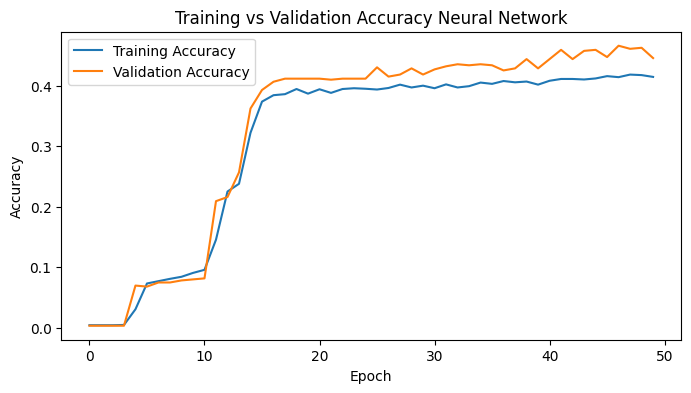

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy Neural Network")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


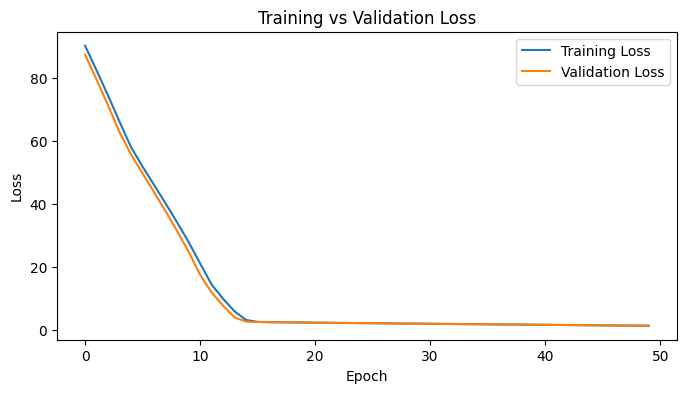

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


## 9. Predictions

In [12]:
y_train_pred_probs = model.predict(X_train)
y_test_pred_probs = model.predict(X_test)

print(y_test_pred_probs[:5])

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[[8.4059557e-04 2.4514612e-02 2.8067955e-01 5.2528238e-01 1.5613976e-01
  1.2543121e-02 1.8093614e-08]
 [8.8024968e-03 1.2599795e-02 2.2251126e-01 5.2930307e-01 1.9425483e-01
  3.2526813e-02 1.7479355e-06]
 [5.7293150e-06 1.0522712e-02 1.6463444e-02 9.0098834e-01 5.7447013e-02
  1.4572631e-02 7.9943696e-08]
 [1.5380710e-03 2.9078297e-02 3.0927593e-01 4.1179782e-01 2.1471061e-01
  3.3598389e-02 9.1974397e-07]
 [4.2262282e-02 1.0004924e-02 8.3108187e-01 5.1934939e-02 6.2054861e-02
  2.6610217e-03 2.3509619e-09]]


## 10. Metrics calculation and classification report.

### Metrics function

In [13]:
def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


### Results

In [14]:
evaluate_model(y_train_encoded, y_train_pred, "Training")
print()
evaluate_model(y_test_encoded, y_test_pred, "Test")


Training Results
---------------------
Accuracy : 0.4268
Precision: 0.3537
Recall   : 0.4268
F1 Score : 0.3567

Test Results
---------------------
Accuracy : 0.4357
Precision: 0.3635
Recall   : 0.4357
F1 Score : 0.3652


### Classification report

In [15]:
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=[str(label) for label in encoder.classes_],
        zero_division=0
    )
)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        33
           5       0.38      0.36      0.37       291
           6       0.46      0.73      0.56       440
           7       0.25      0.01      0.01       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.44       980
   macro avg       0.16      0.16      0.14       980
weighted avg       0.36      0.44      0.37       980



## 11. Confusion matrix

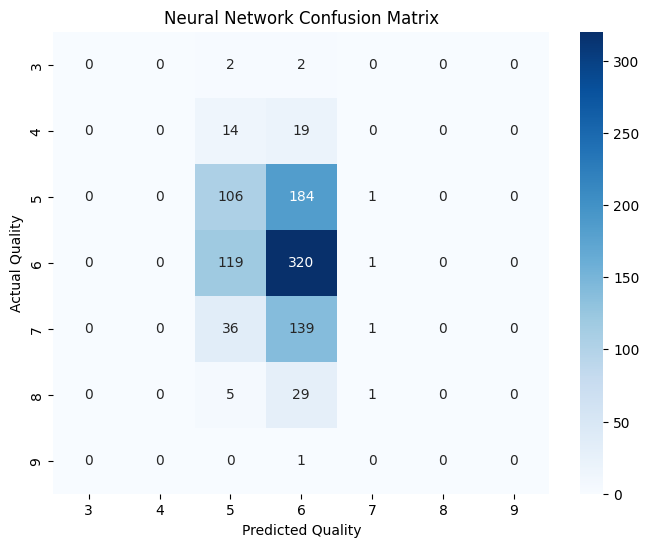

In [16]:
cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.show()
